# 8장. 작은 데이터 분석 프로젝트 완성하기

이 노트북은 **질문 → 원본 데이터 점검 → 전처리 → PK/FK 검증 → 안전한 병합 → completed 범위 집계 → 총합 대조 → 시각화 → 보고서 → 최종 Validation**을 하나의 재현 가능한 프로젝트로 연결합니다.

> 코드가 끝까지 실행되었다는 사실만으로 프로젝트가 검증된 것은 아닙니다. 같은 의미의 숫자와 공개 산출물이 정해 둔 기준을 함께 통과해야 합니다.


## 학습 목표

- 원본 데이터를 보존하며 전처리합니다.
- 주요 PK의 결측·중복과 FK 미매칭을 확인합니다.
- `validate`와 `indicator` 관점으로 병합 결과를 검증합니다.
- `line_total = quantity × unit_price`를 다시 확인합니다.
- 금액성 분석은 `order_status == "completed"` 범위를 사용합니다.
- 카테고리·월·고객 금액 합계를 같은 source total과 대조합니다.
- 날짜 오류로 월별 금액이 누락되지 않는지 확인합니다.
- 공개 고객 결과에서 원본 고객 ID와 직접 식별정보를 제거합니다.
- 결과 CSV, 그래프, Markdown 보고서와 PASS/FAIL Evidence를 저장합니다.
- 전체 파이프라인을 다시 실행해 재현성을 확인합니다.


## 프로젝트 질문

### 분석 질문
1. 카테고리별 completed 주문 기준 금액은 어떻게 다른가?
2. 월별 completed 주문 기준 금액과 주문 수는 어떻게 변하는가?
3. completed 주문 기준 고객별 구매 금액은 어떻게 다른가?

### 분석 범위와 지표
- 분석 대상: 온라인 쇼핑몰 주문 데이터
- 분석 범위: `order_status == "completed"`인 주문
- 사용 데이터: customers, products, orders, order_items
- 사용 지표: 카테고리·월별·고객별 구매 금액과 주문 수

### 계산 기준
- `order_status == "completed"` 적용 여부: 예. completed 주문 상세 474행을 금액 분석에 사용했다.
- `line_total = quantity × unit_price` 확인 여부: 예. 764행 전체에서 불일치 0건으로 PASS했다.

### 완료 기준
카테고리·월별·고객별 completed 주문 기준 금액을 계산하고, 세 결과의 총합이 completed source total과 일치하면 완료로 판단한다.


## 1. 프로젝트 루트와 출력 폴더 설정

VS Code에서 현재 작업 폴더가 프로젝트 루트 또는 `notebooks`일 수 있으므로 상위 폴더를 탐색합니다.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd


def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트 폴더를 찾을 수 없습니다.")


PROJECT_ROOT = Path(r"C:\dev\ai-data-analysis\00_llm-data-analysis-course").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

for path in [PROCESSED_DIR, REPORT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Python 실행 파일:", sys.executable)
print("프로젝트 루트:", PROJECT_ROOT)
print("원본 데이터 폴더:", RAW_DIR)
print("보고서 폴더:", REPORT_DIR)


Python 실행 파일: C:\Users\dydtl\AppData\Local\Programs\Python\Python314\python.exe
프로젝트 루트: C:\dev\ai-data-analysis\00_llm-data-analysis-course
원본 데이터 폴더: C:\dev\ai-data-analysis\00_llm-data-analysis-course\data\raw
보고서 폴더: C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports


## 2. 프로젝트 함수 불러오기

Notebook과 일괄 실행 스크립트가 같은 `src.midterm_project` 함수를 사용하도록 하여 계산 기준이 어긋나는 문제를 줄입니다.


In [2]:
from src.data_loader import load_sales_data
from src.preprocessing import (
    compare_shapes,
    preprocess_sales_data,
    save_processed_data,
    validate_relationships,
)
from src.midterm_project import (
    FORBIDDEN_CUSTOMER_COLUMNS,
    build_analysis_tables,
    build_interpretation_notes,
    build_key_duplicate_checks,
    build_midterm_report,
    build_project_validation,
    create_project_figures,
    run_midterm_project,
    save_project_tables,
    summarize_datasets,
)


## 3. 원본 데이터 확인

프로젝트는 `data/raw`의 원본 4개 파일에서 시작합니다. 파일이 없다면 프로젝트 루트에서 `python scripts/generate_sample_data.py`를 먼저 실행합니다.


In [3]:
raw_data = load_sales_data(RAW_DIR)

dataset_summary = summarize_datasets(raw_data)
display(dataset_summary)

for name, df in raw_data.items():
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("missing values:", int(df.isna().sum().sum()))
    print("duplicated rows:", int(df.duplicated().sum()))


,dataset,rows,columns,missing_values,duplicated_rows
0,customers,150,6,0,0
1,products,100,4,0,0
2,orders,300,5,0,0
3,order_items,764,5,0,0



===== customers =====
shape: (150, 6)
columns: ['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']
missing values: 0
duplicated rows: 0

===== products =====
shape: (100, 4)
columns: ['product_id', 'product_name', 'category', 'price']
missing values: 0
duplicated rows: 0

===== orders =====
shape: (300, 5)
columns: ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
missing values: 0
duplicated rows: 0

===== order_items =====
shape: (764, 5)
columns: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']
missing values: 0
duplicated rows: 0


## 4. 원본을 보존하며 전처리

`preprocess_sales_data()`는 원본 DataFrame을 직접 수정하지 않고 전처리된 복사본을 반환합니다. 전처리 전후 행 수가 달라졌다면 그 이유를 설명할 수 있어야 합니다.


In [4]:
processed_data = preprocess_sales_data(raw_data)
processed_paths = save_processed_data(processed_data, PROCESSED_DIR)

preprocessing_comparison = compare_shapes(raw_data, processed_data)
display(preprocessing_comparison)

for path in processed_paths:
    print(path, "OK" if path.exists() else "MISSING")


,dataset,rows_raw,columns_raw,rows_processed,columns_processed
0,customers,150,6,150,6
1,order_items,764,5,764,6
2,orders,300,5,300,7
3,products,100,4,100,4


C:\dev\ai-data-analysis\00_llm-data-analysis-course\data\processed\customers_clean.csv OK
C:\dev\ai-data-analysis\00_llm-data-analysis-course\data\processed\products_clean.csv OK
C:\dev\ai-data-analysis\00_llm-data-analysis-course\data\processed\orders_clean.csv OK
C:\dev\ai-data-analysis\00_llm-data-analysis-course\data\processed\order_items_clean.csv OK


## 입력 데이터와 전처리 검증

- 사용 원본 파일: customers.csv, products.csv, orders.csv, order_items.csv
- shape:
  - customers: 150행 6열 → 150행 6열
  - products: 100행 4열 → 100행 4열
  - orders: 300행 5열 → 300행 7열
  - order_items: 764행 5열 → 764행 6열
- 핵심 결측/중복 결과: 원본 데이터 4종 모두 결측치 0건, 전체 행 중복 0건을 확인했다.
- 전처리 전후 변화: 모든 데이터셋에서 행 수는 유지되었고, orders에는 날짜 기반 파생 컬럼 2개, order_items에는 `line_total` 컬럼이 추가되었다.

![입력 데이터 검증](images/step02_data_validation.png)

### 나의 해석과 판단
원본 행을 삭제하지 않고 분석에 필요한 날짜 및 금액 정보를 추가하는 방식으로 전처리했다. 따라서 이후 분석에서 관측 건수는 유지된다.

### 한계와 추가 확인 사항
행 수가 유지되었다고 해서 모든 데이터 품질 문제가 해결된 것은 아니다. 이후 PK/FK, 병합, 금액 계산 관계를 별도로 검증한다.


## 5. PK와 FK를 먼저 검증

전체 행 중복과 PK 중복은 다릅니다. 고객·상품·주문·주문 상세의 PK는 **결측 0, 중복 0**이어야 합니다. FK는 부모 테이블에 없는 참조 ID가 0건이어야 합니다.


In [5]:
key_duplicate_checks = build_key_duplicate_checks(processed_data)
relationship_checks = validate_relationships(processed_data).copy()

if not relationship_checks.empty:
    relationship_checks["status"] = (
        relationship_checks["invalid_count"]
        .eq(0)
        .map({True: "PASS", False: "FAIL"})
    )

display(key_duplicate_checks)
display(relationship_checks)

assert key_duplicate_checks["status"].eq("PASS").all(), "PK Validation 실패"
assert (
    not relationship_checks.empty
    and relationship_checks["invalid_count"].eq(0).all()
), "FK Validation 실패"

print("PK/FK Gate: PASS")


,dataset,key,missing_count,duplicate_count,status,detail
0,customers,customer_id,0,0,PASS,
1,products,product_id,0,0,PASS,
2,orders,order_id,0,0,PASS,
3,order_items,order_item_id,0,0,PASS,


,check,invalid_count,status
0,orders.customer_id exists in customers.custome...,0,PASS
1,order_items.order_id exists in orders.order_id,0,PASS
2,order_items.product_id exists in products.prod...,0,PASS


PK/FK Gate: PASS


## 6. 안전한 병합과 계산 관계 검증

`build_analysis_tables()`는 다음을 한 번에 준비합니다.

- 주문 상세 → 주문: `many_to_one`
- 주문 상세 → 상품: `many_to_one`
- 고객 집계 → 고객: `one_to_one`
- 병합 전후 행 수와 미매칭 확인
- `line_total = quantity × unit_price` 확인
- completed 주문 범위 확정
- 날짜 오류 확인


In [6]:
analysis_tables = build_analysis_tables(processed_data)

display(analysis_tables["merge_checks"])
display(analysis_tables["line_total_check"])
display(analysis_tables["date_checks"])
display(analysis_tables["amount_scope_summary"])

assert analysis_tables["merge_checks"]["status"].eq("PASS").all()
assert analysis_tables["line_total_check"]["status"].eq("PASS").all()

print("병합 / line_total Gate: PASS")


,merge,validate,before_rows,after_rows,row_count_preserved,unmatched_count,status
0,order_id → orders,many_to_one,764,764,True,0,PASS
1,product_id → products,many_to_one,474,474,True,0,PASS
2,customer_id → customers,one_to_one,100,100,True,0,PASS


,check,source,row_count,mismatch_count,status
0,line_total = quantity × unit_price,existing,764,0,PASS


,check,invalid_count,affected_amount,status
0,completed rows with invalid order_date,0,0.0,PASS


,scope,amount,detail_rows
0,all_order_items,255610000.0,764
1,completed_order_items,148990000.0,474
2,excluded_non_completed,106620000.0,290


병합 / line_total Gate: PASS


## PK/FK·병합 검증

### PK 결과
- customers.`customer_id`, products.`product_id`, orders.`order_id`, order_items.`order_item_id`는 모두 결측 0건·중복 0건으로 PASS했다.

### FK 결과
- orders → customers, order_items → orders, order_items → products 관계의 미매칭은 모두 0건으로 PASS했다.

### 병합과 계산 결과
- order_id → orders: `many_to_one`, 764행 → 764행, 미매칭 0건, PASS
- product_id → products: `many_to_one`, 474행 → 474행, 미매칭 0건, PASS
- customer_id → customers: `one_to_one`, 100행 → 100행, 미매칭 0건, PASS
- `line_total = quantity × unit_price` 불일치: 0건, PASS

### 나의 해석과 판단
키와 관계 검증을 통과했고 병합 전후 행 수도 유지되었다. 중복 키에 따른 행 증식이나 부모 테이블에 없는 참조 ID 없이 분석용 테이블을 구성했다고 판단했다.

### 한계와 추가 확인 사항
병합 구조와 계산 관계는 확인했지만, completed 범위와 카테고리·월별·고객별 총합의 일치는 다음 단계에서 추가 검증한다.


## 7. 핵심 분석 결과 확인

세 금액성 결과는 같은 `completed_order_sales`에서 출발합니다. 주문 상태 분포만 전체 주문을 사용합니다.


In [7]:
category_sales = analysis_tables["category_sales"]
monthly_sales = analysis_tables["monthly_sales"]
customer_sales_internal = analysis_tables["customer_sales"]
customer_sales_public = analysis_tables["customer_sales_public"]
order_status_summary = analysis_tables["order_status_summary"]

display(category_sales)
display(monthly_sales)
display(customer_sales_public.head(10))
display(order_status_summary)

print("내부 고객 결과 컬럼:", customer_sales_internal.columns.tolist())
print("공개 고객 결과 컬럼:", customer_sales_public.columns.tolist())


,category,total_quantity,total_sales,sales_ratio
0,스포츠,295,31743000,21.31
1,전자기기,259,26400000,17.72
2,생활용품,272,23915000,16.05
3,뷰티,223,23383000,15.69
4,식품,133,16573000,11.12
5,도서,149,16389000,11.00
6,패션,111,10587000,7.11


,order_month,total_sales,order_count,avg_order_value
0,2025-07,5869000,8,733625.0
1,2025-08,15621000,18,867833.0
2,2025-09,10190000,13,783846.0
3,2025-10,25766000,26,991000.0
4,2025-11,8812000,12,734333.0
5,2025-12,11501000,14,821500.0
6,2026-01,17423000,22,791955.0
7,2026-02,9749000,17,573471.0
8,2026-03,13429000,14,959214.0
9,2026-04,17553000,23,763174.0


,customer_label,city,order_count,total_sales,avg_order_value
0,Customer 01,성남,5,4100000,820000.0
1,Customer 02,고양,4,3996000,999000.0
2,Customer 03,수원,4,3880000,970000.0
3,Customer 04,서울,5,3590000,718000.0
4,Customer 05,서울,4,3523000,880750.0
5,Customer 06,인천,2,3191000,1595500.0
6,Customer 07,성남,2,3178000,1589000.0
7,Customer 08,광주,3,3153000,1051000.0
8,Customer 09,서울,4,3093000,773250.0
9,Customer 10,부산,2,2990000,1495000.0


,order_status,order_count,order_ratio
0,completed,184,61.33
1,cancelled,64,21.33
2,refunded,52,17.33


내부 고객 결과 컬럼: ['customer_id', 'customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']
공개 고객 결과 컬럼: ['customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']


## 핵심 EDA 결과

### 결과 1. 카테고리별 completed 주문 기준 금액
- 관찰: 스포츠는 31,743,000원(21.32%)으로 가장 높고, 패션은 10,587,000원(7.11%)으로 가장 낮았다.
- 해석과 판단: completed 주문 금액 기준으로 스포츠 카테고리의 기여가 가장 크다. 판매 수량과 평균 단가를 분리해 확인할 필요가 있다.
- 업무·분석적 의미: 카테고리별 금액 기여도를 추가 분석이나 운영 우선순위 검토에 활용할 수 있다.
- 한계: 현재 데이터만으로 수익성, 고객 선호, 광고 효과를 판단할 수 없다.

### 결과 2. 월별 completed 주문 기준 금액과 주문 수
- 관찰: 2025년 10월은 25,766,000원·26건으로 가장 높았고, 2026년 6월은 2,826,000원·4건, 7월은 2,188,000원·2건이었다.
- 해석과 판단: 월별 금액 변화는 주문 수 변화와 함께 나타나는 경향이 있다.
- 업무·분석적 의미: 주문 수와 평균 주문 금액을 분리해 보면 월별 변동의 형태를 더 구체적으로 확인할 수 있다.
- 한계: 프로모션, 광고, 계절성, 재고 정보가 없어 월별 변동 원인을 단정할 수 없다.

### 결과 3. completed 주문 기준 고객별 구매 금액
- 관찰: Customer 01은 4,100,000원·5건으로 가장 높았고, Customer 02는 3,996,000원·4건, Customer 03은 3,880,000원·4건이었다.
- 해석과 판단: 고객별 총 구매 금액만으로는 반복 구매와 일회성 고액 구매를 구분할 수 없다.
- 업무·분석적 의미: 이후 구매 빈도, 최근 구매일, 평균 주문 금액을 함께 분석할 수 있다.
- 한계: 고객별 구매 금액은 고객 가치나 만족도를 뜻하지 않으며 개인 평가 목적으로 사용하면 안 된다.


## 8. 같은 의미의 금액 총합을 교차 검증

같은 completed 범위에서 만든 결과라면 다음 네 금액이 일치해야 합니다.

```text
completed source total
= category total
= monthly total
= customer total
```

날짜 오류가 있으면 월별 합계가 source total보다 작아질 수 있으므로 별도 Gate로 확인합니다.


In [8]:
total_consistency = analysis_tables["total_consistency_check"]
display(total_consistency)

assert total_consistency["matches_completed"].all(), "Total consistency Gate 실패"
assert analysis_tables["date_checks"]["status"].eq("PASS").all(), "날짜 Gate 실패"

print("Total consistency / Date Gate: PASS")


,source,amount,difference_from_completed,matches_completed,status
0,completed_source,148990000.0,0.0,True,PASS
1,category,148990000.0,0.0,True,PASS
2,monthly,148990000.0,0.0,True,PASS
3,customer,148990000.0,0.0,True,PASS


Total consistency / Date Gate: PASS


## Total consistency와 날짜 검증

- completed source total, category total, monthly total, customer total은 모두 148,990,000원으로 일치했다.
- 총합 일치 여부: PASS
- completed 주문 날짜 오류 건수: 0건
- 날짜 오류 영향 금액: 0원

### 나의 해석과 판단
같은 completed 주문 상세에서 출발한 카테고리·월별·고객별 집계가 동일한 총액으로 수렴함을 확인했다. 따라서 분석 결과가 서로 다른 필터나 병합 오류로 왜곡되지 않았다고 판단했다.

### 불일치가 있었다면 확인할 사항
completed 필터 누락, 병합 행 증식, 키 미매칭, category 결측, 날짜 변환 실패, 고객 연결 누락을 우선 점검한다.


## 9. 공개 고객 결과의 개인정보를 확인

내부 계산에는 `customer_id`가 필요할 수 있지만 공개 CSV·그래프·보고서에는 원본 고객 ID와 직접 식별정보를 포함하지 않습니다. 공개 라벨은 `Customer 01` 같은 순위 기반 라벨을 사용합니다.


In [9]:
forbidden = sorted(
    FORBIDDEN_CUSTOMER_COLUMNS.intersection(customer_sales_public.columns)
)
print("공개 결과 금지 컬럼:", forbidden)

assert not forbidden, "Privacy Gate 실패"
assert "customer_id" not in customer_sales_public.columns
print("Privacy Gate: PASS")


공개 결과 금지 컬럼: []
Privacy Gate: PASS


## 개인정보 검증

- 공개 고객 CSV 컬럼: customer_label, city, order_count, total_sales, avg_order_value
- 원본 `customer_id` 포함 여부: 아니오
- 이름·이메일·전화번호·주소 포함 여부: 아니오
- 익명 라벨 방식: 구매 금액 순위 기반 `Customer 01` 형식
- 검증 결과: PASS

### 나의 판단
내부 계산에는 고객 ID를 사용하되, 공개 결과에서는 원본 ID와 직접 식별정보를 제거했다. 따라서 분석에 필요한 요약 정보만 공개했다.


## 10. 최종 PASS/FAIL Validation

지금까지의 핵심 Gate를 하나의 표로 정리합니다. 하나라도 FAIL이면 결과를 제출 가능한 완료 상태로 보지 않습니다.


In [10]:
project_validation = build_project_validation(
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
)
display(project_validation)

assert project_validation["status"].eq("PASS").all(), "최종 Validation 실패"
print("Project Validation: PASS")


,check,value,expected,status
0,pk_integrity,all PASS,all PASS,PASS
1,fk_integrity,0,0,PASS
2,merge_checks_pass,all PASS,all PASS,PASS
3,line_total_consistency,0,0,PASS
4,completed_total_consistency,all match,all match,PASS
5,category_sales_ratio_pct_sum,100.0,100.0,PASS
6,completed_rows_with_invalid_order_date,0,0,PASS
7,public_customer_columns_safe,no forbidden columns,no forbidden columns,PASS


Project Validation: PASS


## 최종 Validation

| 검증 항목 | 결과 | 내가 확인한 근거 |
| --- | --- | --- |
| pk_integrity | PASS | 주요 PK 결측·중복 0건 |
| fk_integrity | PASS | FK 미매칭 0건 |
| merge_checks_pass | PASS | 세 병합의 validate·행 수·미매칭 검증 통과 |
| line_total_consistency | PASS | 불일치 0건 |
| completed_total_consistency | PASS | category/month/customer 총합이 source total과 일치 |
| category_sales_ratio_pct_sum | PASS | 비중 합계 100.0% |
| completed_rows_with_invalid_order_date | PASS | 날짜 오류 0건 |
| public_customer_columns_safe | PASS | 금지 컬럼 없음 |

### FAIL이 있었다면 수정 내용
최종 실행에서는 모든 항목이 PASS였으므로 추가 수정 사항은 없다.


## 11. 해석 메모와 결과 CSV 저장

관찰, 주의점, 다음 질문을 분리합니다. 저장되는 `ch08_customer_sales.csv`는 공개용 컬럼만 포함합니다.


In [11]:
interpretation_notes = build_interpretation_notes()
display(interpretation_notes)

saved_tables = save_project_tables(
    dataset_summary,
    preprocessing_comparison,
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
    interpretation_notes,
    REPORT_DIR,
)

for path in saved_tables:
    print(path.name, path.exists(), path.stat().st_size)


,analysis,observation,caution,next_question
0,카테고리별 completed 주문 기준 금액,completed 주문 기준 금액 비중이 높은 카테고리를 확인할 수 있습니다.,금액이 높은 이유가 판매 수량인지 단가인지 구분해야 합니다.,카테고리별 평균 판매 단가는 어떻게 다른가?
1,월별 completed 주문 기준 금액,시간에 따른 completed 주문 기준 금액의 증가와 감소를 확인할 수 있습니다.,프로모션이나 계절성이 원인이라고 단정할 수 없습니다.,주문 수와 평균 주문 금액 중 무엇이 변했는가?
2,고객별 completed 주문 구매 금액,completed 주문 기준 구매 금액이 높은 고객군을 확인할 수 있습니다.,일회성 고액 구매와 반복 구매를 구분해야 합니다.,최근 구매일과 구매 빈도는 어떻게 다른가?
3,주문 상태별 주문 수,"완료, 취소, 환불 주문의 분포를 확인할 수 있습니다.",주문 상태의 정의와 처리 기준을 확인해야 합니다.,취소율과 환불률은 월별로 달라지는가?


ch08_dataset_summary.csv True 138
ch08_preprocessing_comparison.csv True 156
ch08_key_duplicate_checks.csv True 188
ch08_relationship_checks.csv True 206
ch08_merge_checks.csv True 253
ch08_line_total_check.csv True 106
ch08_date_checks.csv True 98
ch08_amount_scope_summary.csv True 141
ch08_total_consistency_check.csv True 220
ch08_project_validation.csv True 394
ch08_category_sales.csv True 254
ch08_monthly_sales.csv True 438
ch08_customer_sales.csv True 3960
ch08_order_status_summary.csv True 101
ch08_interpretation_notes.csv True 1089


## 12. 저장된 공개 고객 CSV를 다시 검사

메모리의 DataFrame만 보지 않고 실제 저장된 CSV를 다시 읽어 개인정보 컬럼이 남지 않았는지 확인합니다.


In [12]:
saved_customer = pd.read_csv(REPORT_DIR / "ch08_customer_sales.csv")

saved_forbidden = sorted(
    FORBIDDEN_CUSTOMER_COLUMNS.intersection(saved_customer.columns)
)
print("저장 CSV 컬럼:", saved_customer.columns.tolist())
print("금지 컬럼:", saved_forbidden)

assert not saved_forbidden
print("저장된 고객 CSV Privacy Gate: PASS")


저장 CSV 컬럼: ['customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']
금지 컬럼: []
저장된 고객 CSV Privacy Gate: PASS


## 13. 검증된 집계표에서 그래프 생성

그래프는 새로운 계산 범위를 만드는 단계가 아니라 검증된 숫자를 전달하는 단계입니다.


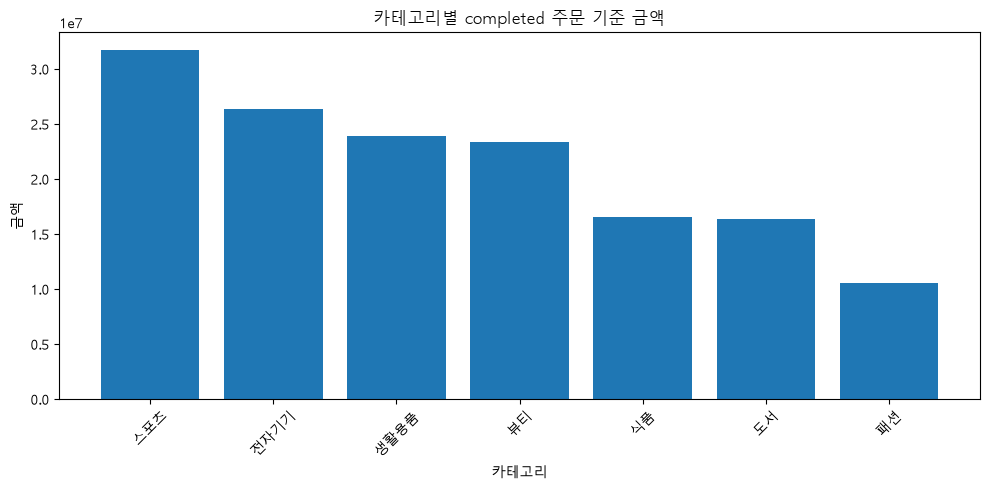

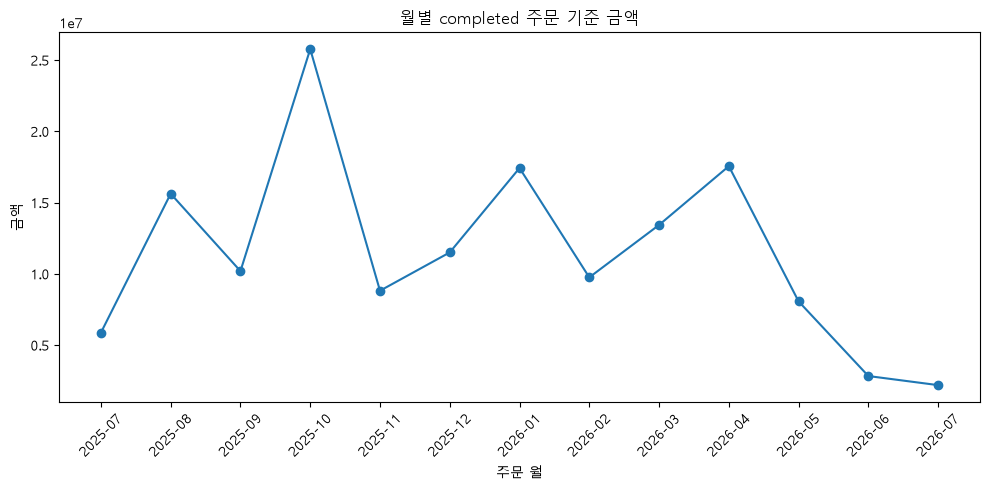

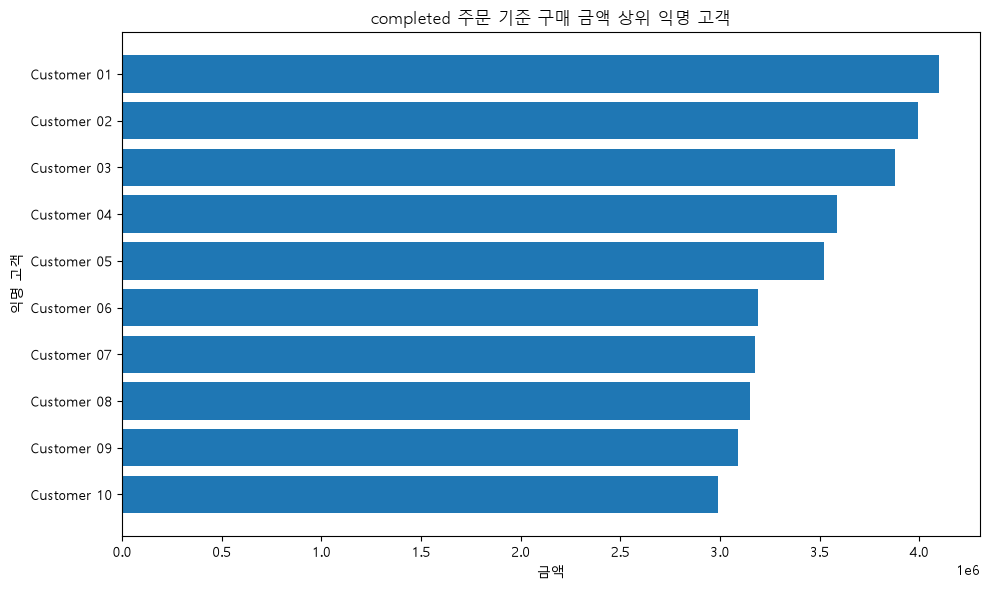

ch08_category_sales.png True 28333
ch08_monthly_sales.png True 75220
ch08_top_customers.png True 47302


In [13]:
saved_figures = create_project_figures(
    analysis_tables,
    FIGURE_DIR,
    show=True,
)

for path in saved_figures:
    print(path.name, path.exists(), path.stat().st_size)


## 대표 시각화

![카테고리별 completed 주문 기준 금액](images/graph01.png)

![월별 completed 주문 기준 금액](images/graph02.png)

### 그래프 선택 이유
카테고리별 막대그래프는 카테고리 간 금액 기여를 비교하기에 적합하고, 월별 선그래프는 시간에 따른 금액 변동을 확인하기에 적합하다.

### 그래프와 원본 집계값 일치 여부
두 그래프는 검증된 카테고리별·월별 집계표에서 생성했고, 각 집계의 총합은 completed source total과 일치한다.

### 그래프에서 직접 관찰한 사실
스포츠 카테고리의 금액이 가장 높고 패션이 가장 낮았다. 월별 금액은 2025년 10월에 가장 높았으며 월별 변동이 있었다.

### 그래프만으로 말할 수 없는 것
광고, 프로모션, 재고, 원가, 고객 만족도 정보가 없으므로 카테고리·월별 차이의 원인이나 수익성을 단정할 수 없다.


## 14. Markdown 보고서 생성

보고서에는 계산 기준, PK/FK·병합, `line_total`, total consistency, 개인정보, 최종 Validation을 함께 남깁니다.


In [14]:
report_text = build_midterm_report(
    dataset_summary,
    preprocessing_comparison,
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
    interpretation_notes,
)

report_path = REPORT_DIR / "ch08_midterm_report.md"
report_path.write_text(report_text, encoding="utf-8")

print("보고서 저장:", report_path)
print(report_text[:1800])


보고서 저장: C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\ch08_midterm_report.md
# Chapter 8 중간 프로젝트 보고서

## 1. 분석 목적

온라인 쇼핑몰 데이터를 사용해 completed 주문 기준 금액과 고객 구매 패턴을 분석했습니다.

## 2. 분석 기준

- 금액성 분석은 `order_status == "completed"`인 주문만 포함했습니다.
- `line_total = quantity × unit_price` 관계를 검증했습니다.
- 취소·환불 등 non-completed 주문을 포함한 금액은 전체 주문 상세 금액으로 구분했습니다.
- 공개 고객 결과에서는 이름·연락처·원본 고객 ID를 제외하고 순위 기반 익명 라벨을 사용했습니다.
- 병합은 관계 검증, `validate`, 행 수, 미매칭을 확인했습니다.
- 같은 completed 범위의 카테고리·월·고객 총합을 source total과 대조했습니다.

## 3. 데이터 개요

```text
    dataset  rows  columns  missing_values  duplicated_rows
  customers   150        6               0                0
   products   100        4               0                0
     orders   300        5               0                0
order_items   764        5               0                0
```

## 4. 전처리 전후 비교

```text
    dataset  rows_raw  columns_raw  rows_processed  columns_processed
  customers       150            6             150            

## 15. 전체 파이프라인 재실행

단계별 셀을 확인한 뒤에는 `run_midterm_project()`로 원본부터 보고서까지 다시 실행합니다. Notebook의 이전 메모리 상태에 의존하지 않는지 확인하는 단계입니다.


In [15]:
project_result = run_midterm_project(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    report_dir=REPORT_DIR,
    figure_dir=FIGURE_DIR,
    show_figures=False,
)

display(project_result["project_validation"])
project_result["report_path"]


,check,value,expected,status
0,pk_integrity,all PASS,all PASS,PASS
1,fk_integrity,0,0,PASS
2,merge_checks_pass,all PASS,all PASS,PASS
3,line_total_consistency,0,0,PASS
4,completed_total_consistency,all match,all match,PASS
5,category_sales_ratio_pct_sum,100.0,100.0,PASS
6,completed_rows_with_invalid_order_date,0,0,PASS
7,public_customer_columns_safe,no forbidden columns,no forbidden columns,PASS


WindowsPath('C:/dev/ai-data-analysis/00_llm-data-analysis-course/reports/ch08_midterm_report.md')

## 16. 최종 산출물 검증

필수 CSV·PNG·Markdown이 존재하고 비어 있지 않은지 확인합니다.


In [16]:
expected_outputs = [
    REPORT_DIR / "ch08_midterm_report.md",
    REPORT_DIR / "ch08_dataset_summary.csv",
    REPORT_DIR / "ch08_preprocessing_comparison.csv",
    REPORT_DIR / "ch08_key_duplicate_checks.csv",
    REPORT_DIR / "ch08_relationship_checks.csv",
    REPORT_DIR / "ch08_merge_checks.csv",
    REPORT_DIR / "ch08_line_total_check.csv",
    REPORT_DIR / "ch08_date_checks.csv",
    REPORT_DIR / "ch08_amount_scope_summary.csv",
    REPORT_DIR / "ch08_total_consistency_check.csv",
    REPORT_DIR / "ch08_project_validation.csv",
    REPORT_DIR / "ch08_category_sales.csv",
    REPORT_DIR / "ch08_monthly_sales.csv",
    REPORT_DIR / "ch08_customer_sales.csv",
    REPORT_DIR / "ch08_order_status_summary.csv",
    REPORT_DIR / "ch08_interpretation_notes.csv",
    FIGURE_DIR / "ch08_category_sales.png",
    FIGURE_DIR / "ch08_monthly_sales.png",
    FIGURE_DIR / "ch08_top_customers.png",
]

all_outputs_valid = True
for path in expected_outputs:
    valid = path.exists() and path.stat().st_size > 0
    all_outputs_valid &= valid
    print(path.name, "OK" if valid else "MISSING OR EMPTY")

assert all_outputs_valid
print("전체 산출물 검증: PASS")


ch08_midterm_report.md OK
ch08_dataset_summary.csv OK
ch08_preprocessing_comparison.csv OK
ch08_key_duplicate_checks.csv OK
ch08_relationship_checks.csv OK
ch08_merge_checks.csv OK
ch08_line_total_check.csv OK
ch08_date_checks.csv OK
ch08_amount_scope_summary.csv OK
ch08_total_consistency_check.csv OK
ch08_project_validation.csv OK
ch08_category_sales.csv OK
ch08_monthly_sales.csv OK
ch08_customer_sales.csv OK
ch08_order_status_summary.csv OK
ch08_interpretation_notes.csv OK
ch08_category_sales.png OK
ch08_monthly_sales.png OK
ch08_top_customers.png OK
전체 산출물 검증: PASS


## 프로젝트 재현 확인

- `python scripts/run_midterm_project.py` 실행 여부: 예
- 재실행 결과: 원본 데이터 로드부터 전처리, PK/FK 검증, 병합, 집계, 그래프, Markdown 보고서 생성까지 전체 파이프라인을 다시 실행했다.
- 최종 Validation 결과: PASS
- Notebook과 핵심 수치 일치 여부: 일치
- 생성된 핵심 Evidence 파일 확인 여부: CSV, 그래프 PNG, Markdown 보고서가 모두 생성된 것을 확인했다.

![재실행 결과](images/step06_reproduce.png)

### 나의 해석과 판단
단계별 실행은 이전 메모리 값에 의존할 수 있다. 전체 파이프라인을 원본 데이터부터 다시 실행하고 산출물 검증까지 PASS한 결과를 확인해, 같은 조건에서 분석 결과를 다시 만들 수 있음을 확인했다.


## 17. LLM 검토 프롬프트 예시

원본 고객 행이나 직접 식별정보 대신 비식별 검증 Evidence를 제공합니다.

```text
온라인 쇼핑몰 중간 프로젝트 결과를 검토해 주세요.

계산 기준:
- line_total = quantity × unit_price
- 금액성 분석은 order_status == completed만 사용

검증 결과:
- PK 결측/중복: 0
- FK 미매칭: 0
- merge checks: PASS
- category/month/customer totals: source total과 일치
- completed 주문 날짜 오류: 0
- 공개 고객 CSV에 원본 customer_id 없음

다음을 검토해 주세요.
1. 아직 확인하지 않은 분석 위험
2. 과도한 해석이 될 수 있는 표현
3. 보고서에 반드시 적어야 할 계산 기준
4. 추가로 필요한 검증
5. 데이터에 없는 원인은 추정하지 않기
```

LLM은 검토 범위를 넓히는 도구이지 프로젝트의 최종 승인자가 아닙니다.


## LLM 활용 기록

- 사용 여부: 사용
- 사용 목적: Chapter 08 실습 환경 오류를 해결하고, 검증 결과를 답안 형식에 맞게 정리하는 데 참고했다.
- Safe Context: 분석 질문, 컬럼 구조, PK/FK·병합·line_total·total consistency 결과, 익명 집계 결과와 그래프만 제공했다. 원본 고객 행과 직접 식별정보는 제공하지 않았다.
- Prompt 요약: 공식 실습 노트북의 실행 흐름, 프로젝트 경로 설정, 검증 결과의 의미와 답안 Markdown 구성 방법을 질문했다.
- 제안 요약: 계산 기준을 명시하고, 그래프·집계표·총합 검증을 연결하며, 데이터에 없는 원인을 단정하지 않도록 제안받았다.
- 반영/수정/보류: LLM의 설명은 참고용으로 사용했고, 실제 수치와 PASS 여부는 Notebook 실행 결과로 다시 확인했다.
- 사람이 검증한 근거: 원본 데이터, PK/FK, 병합, line_total, 날짜, total consistency, 개인정보, 최종 Validation, 전체 재실행 결과를 직접 확인했다.


## 18. 실습 과제

1. 핵심 EDA 결과 3개를 선택하고 각각 근거와 한계를 작성합니다.
2. 대표 그래프 2~4개를 선택하고 원본 집계값과 일치하는지 확인합니다.
3. `ch08_total_consistency_check.csv`와 `ch08_project_validation.csv`를 확인합니다.
4. 공개 고객 CSV에 개인정보가 없는지 다시 확인합니다.
5. LLM을 사용했다면 목적·Prompt 요약·제안·반영 여부·사람의 검증 근거를 기록합니다.
6. `python scripts/run_midterm_project.py`로 전체 프로젝트를 다시 실행하고 Notebook의 핵심 수치와 비교합니다.


In [17]:
# 실습 과제: 검증된 completed 주문 상세에서 핵심 EDA를 직접 다시 계산합니다.
completed_order_sales = analysis_tables["completed_order_sales"].copy()
completed_sales_items = analysis_tables["completed_sales_items"].copy()

# 결과 1: 카테고리별 completed 주문 기준 금액
assignment_category_sales = (
    completed_sales_items.groupby("category", as_index=False)
    .agg(total_quantity=("quantity", "sum"), total_sales=("line_total", "sum"))
    .sort_values("total_sales", ascending=False)
    .reset_index(drop=True)
)

# 결과 2: 월별 completed 주문 기준 금액과 고유 주문 수
assignment_monthly_sales = (
    completed_order_sales.groupby("order_month", as_index=False)
    .agg(total_sales=("line_total", "sum"), order_count=("order_id", "nunique"))
    .sort_values("order_month")
    .reset_index(drop=True)
)

# 결과 3: 고객별 completed 주문 기준 구매 금액과 고유 주문 수
assignment_customer_sales = (
    completed_order_sales.groupby("customer_id", as_index=False)
    .agg(order_count=("order_id", "nunique"), total_sales=("line_total", "sum"))
    .sort_values("total_sales", ascending=False)
    .reset_index(drop=True)
)

completed_source_total = float(completed_order_sales["line_total"].sum())
assignment_totals = {
    "completed_source": completed_source_total,
    "category": float(assignment_category_sales["total_sales"].sum()),
    "monthly": float(assignment_monthly_sales["total_sales"].sum()),
    "customer": float(assignment_customer_sales["total_sales"].sum()),
}

assert all(np.isclose(value, completed_source_total) for value in assignment_totals.values())

print("=== 결과 1: 카테고리별 completed 주문 기준 금액 ===")
display(assignment_category_sales)
print("=== 결과 2: 월별 completed 주문 기준 금액과 주문 수 ===")
display(assignment_monthly_sales)
print("=== 결과 3: completed 주문 기준 고객별 구매 금액 상위 10명 ===")
display(customer_sales_public.head(10))
print("=== 직접 재계산한 총합 ===")
display(pd.DataFrame(assignment_totals.items(), columns=["source", "total_sales"]))

# 저장된 공개 고객 CSV의 개인정보와 최종 Validation을 재확인합니다.
public_customer_result = pd.read_csv(REPORT_DIR / "ch08_customer_sales.csv")
forbidden_columns = sorted(FORBIDDEN_CUSTOMER_COLUMNS.intersection(public_customer_result.columns))
project_validation_result = pd.read_csv(REPORT_DIR / "ch08_project_validation.csv")
assert not forbidden_columns
assert project_validation_result["status"].eq("PASS").all()
print("공개 고객 CSV 금지 컬럼:", forbidden_columns)
print("Chapter 08 실습 과제 핵심 검증: PASS")


=== 결과 1: 카테고리별 completed 주문 기준 금액 ===


,category,total_quantity,total_sales
0,스포츠,295,31743000
1,전자기기,259,26400000
2,생활용품,272,23915000
3,뷰티,223,23383000
4,식품,133,16573000
5,도서,149,16389000
6,패션,111,10587000


=== 결과 2: 월별 completed 주문 기준 금액과 주문 수 ===


,order_month,total_sales,order_count
0,2025-07,5869000,8
1,2025-08,15621000,18
2,2025-09,10190000,13
3,2025-10,25766000,26
4,2025-11,8812000,12
5,2025-12,11501000,14
6,2026-01,17423000,22
7,2026-02,9749000,17
8,2026-03,13429000,14
9,2026-04,17553000,23


=== 결과 3: completed 주문 기준 고객별 구매 금액 상위 10명 ===


,customer_label,city,order_count,total_sales,avg_order_value
0,Customer 01,성남,5,4100000,820000.0
1,Customer 02,고양,4,3996000,999000.0
2,Customer 03,수원,4,3880000,970000.0
3,Customer 04,서울,5,3590000,718000.0
4,Customer 05,서울,4,3523000,880750.0
5,Customer 06,인천,2,3191000,1595500.0
6,Customer 07,성남,2,3178000,1589000.0
7,Customer 08,광주,3,3153000,1051000.0
8,Customer 09,서울,4,3093000,773250.0
9,Customer 10,부산,2,2990000,1495000.0


=== 직접 재계산한 총합 ===


,source,total_sales
0,completed_source,148990000.0
1,category,148990000.0
2,monthly,148990000.0
3,customer,148990000.0


공개 고객 CSV 금지 컬럼: []
Chapter 08 실습 과제 핵심 검증: PASS


## 최종 프로젝트 요약

### 핵심 인사이트 3개
1. completed 주문 기준 금액에서 스포츠 카테고리의 비중이 가장 높았다.
2. 월별 completed 주문 금액은 변동했으며 2025년 10월이 가장 높았다.
3. 고객별 구매 금액에는 차이가 있으며, 상위 고객의 총 구매 금액만으로 구매 원인을 단정할 수는 없다.

### 가장 중요한 업무·분석적 의미
질문·계산 기준·검증·집계·그래프·해석이 같은 completed 주문 범위를 사용하도록 연결한 점이 가장 중요하다.

### 현재 분석의 한계
광고, 프로모션, 원가, 재고, 고객 만족도 정보가 없어 금액 차이의 원인·수익성·고객 선호를 판단할 수 없다.

### 다음 분석 제안
1. 카테고리별 판매 수량과 평균 판매 단가를 함께 비교한다.
2. 월별 주문 수와 평균 주문 금액을 분리해 변동 원인을 탐색한다.
3. 고객별 최근 구매일과 구매 빈도를 추가해 구매 패턴을 분석한다.


## 정리

이번 장에서는 원본 데이터 확인, 전처리, PK/FK, 병합, `line_total`, completed 범위, total consistency, 날짜, 개인정보, 시각화, 보고서, 최종 Validation을 하나의 프로젝트로 연결했습니다.

기억할 핵심은 다음과 같습니다.

```text
실행 성공 ≠ 검증 완료
같은 의미의 숫자는 서로 다른 집계에서도 같아야 한다
공개 결과에는 불필요한 개인정보를 남기지 않는다
프로젝트는 원본부터 다시 실행할 수 있어야 한다
```
